In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("german_credit_data.csv")

In [3]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
df.columns.to_list()

['Unnamed: 0',
 'Age',
 'Sex',
 'Job',
 'Housing',
 'Saving accounts',
 'Checking account',
 'Credit amount',
 'Duration',
 'Purpose',
 'Risk']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df = df.drop(columns=['Unnamed: 0'])

In [7]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

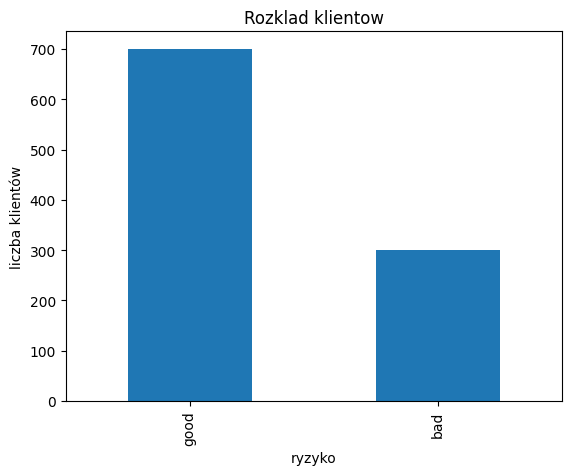

In [8]:
df['Risk'].value_counts().plot(kind='bar')
plt.title('Rozklad klientow')
plt.xlabel('ryzyko')
plt.ylabel('liczba klientów')
plt.show()


In [9]:
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [10]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"\n--- {col} ---")
        print(df[col].value_counts())


--- Sex ---
Sex
male      690
female    310
Name: count, dtype: int64

--- Housing ---
Housing
own     713
rent    179
free    108
Name: count, dtype: int64

--- Saving accounts ---
Saving accounts
little        603
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

--- Checking account ---
Checking account
little      274
moderate    269
rich         63
Name: count, dtype: int64

--- Purpose ---
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

--- Risk ---
Risk
good    700
bad     300
Name: count, dtype: int64


In [11]:
df['Saving accounts'] = df['Saving accounts'].fillna('unoknown')
df['Checking account'] = df['Checking account'].fillna('unoknown')

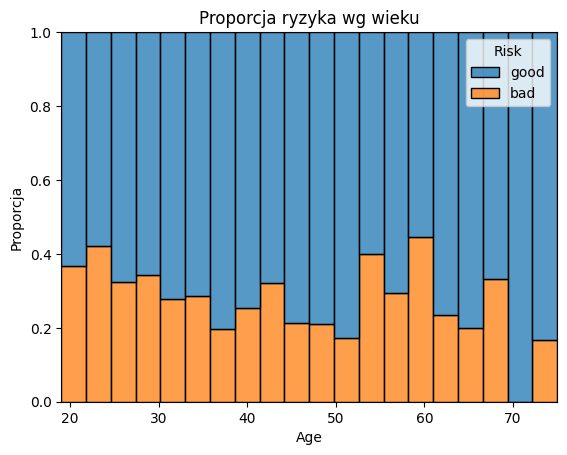

In [12]:
sns.histplot(data=df, x='Age', hue='Risk', bins=20, multiple='fill')
plt.title('Proporcja ryzyka wg wieku')
plt.ylabel('Proporcja')
plt.show()

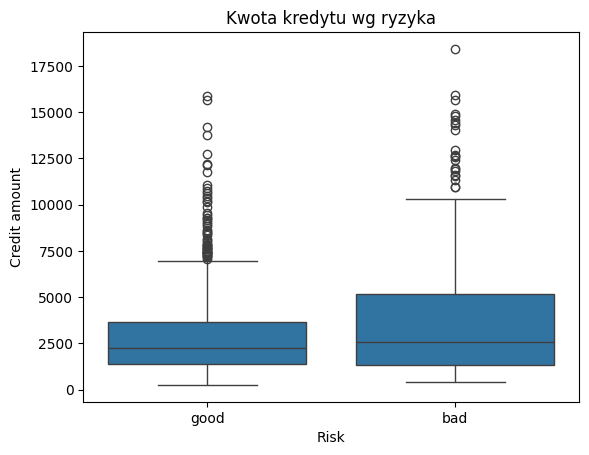

In [13]:
sns.boxplot(data=df, x='Risk', y='Credit amount')
plt.title('Kwota kredytu wg ryzyka')
plt.show()

Im wyższy kredyt tym ciężej go spłacić

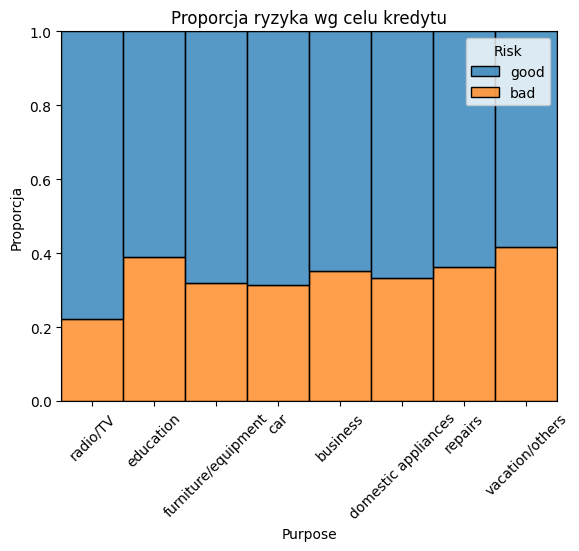

In [14]:
sns.histplot(data=df, x='Purpose', hue='Risk', multiple='fill')
plt.title('Proporcja ryzyka wg celu kredytu')
plt.xticks(rotation=45)
plt.ylabel('Proporcja')
plt.show()

Kredyt np. na wakacje nie jest inwestycją stąd wysoki wpółczynnik niespłacalności?

In [15]:
print(df.dtypes)

Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object


Saving accounts, Checking account → Label Encoding (mają kolejność: little → moderate → rich)
Purpose, Housing, Sex → One-Hot Encoding (brak kolejności)
Risk → Label Encoding (good=1, bad=0 — target)

In [16]:
df['Risk'] = df['Risk'].map({'good':1,'bad':0})
df['Risk'].value_counts()

Risk
1    700
0    300
Name: count, dtype: int64

In [17]:
order_map = {'little': 0, 'moderate': 1, 'quite rich': 2, 'rich': 3, 'unoknown': 4}

df['Saving accounts'] = df['Saving accounts'].map(order_map)
df['Checking account'] = df['Checking account'].map(order_map)

In [18]:
df = pd.get_dummies(df, columns=['Purpose', 'Housing', 'Sex'], drop_first=True)
print(df.columns.tolist())

['Age', 'Job', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Risk', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others', 'Housing_own', 'Housing_rent', 'Sex_male']


In [19]:
df.isna().sum()

Age                            0
Job                            0
Saving accounts                0
Checking account               0
Credit amount                  0
Duration                       0
Risk                           0
Purpose_car                    0
Purpose_domestic appliances    0
Purpose_education              0
Purpose_furniture/equipment    0
Purpose_radio/TV               0
Purpose_repairs                0
Purpose_vacation/others        0
Housing_own                    0
Housing_rent                   0
Sex_male                       0
dtype: int64

In [20]:
X = df.drop(columns=['Risk'])
y = df['Risk']

print(X.shape)
print(y.shape)

(1000, 16)
(1000,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=28, stratify=y)
print(f'Train: {X_train.shape[0]} klientów')
print(f'Test:  {X_test.shape[0]} klientów')

Train: 700 klientów
Test:  300 klientów


In [22]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

Logistic Regression ROC AUC: 0.791
Logistic Regression Confusion Matrix:
[[ 41  49]
 [ 23 187]]
Decision Tree ROC AUC: 0.628
Decision Tree Confusion Matrix:
[[ 44  46]
 [ 49 161]]
Random Forest ROC AUC: 0.759
Random Forest Confusion Matrix:
[[ 39  51]
 [ 28 182]]
Gradient Boosting ROC AUC: 0.764
Gradient Boosting Confusion Matrix:
[[ 35  55]
 [ 27 183]]


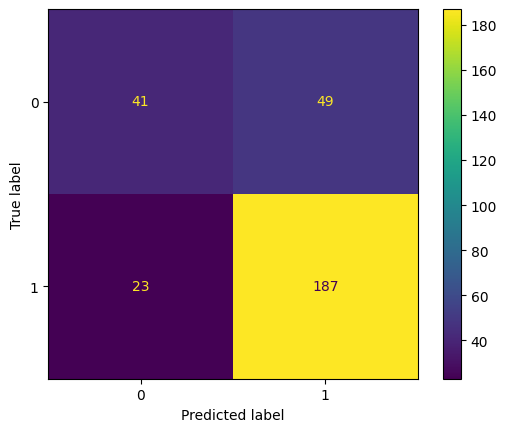

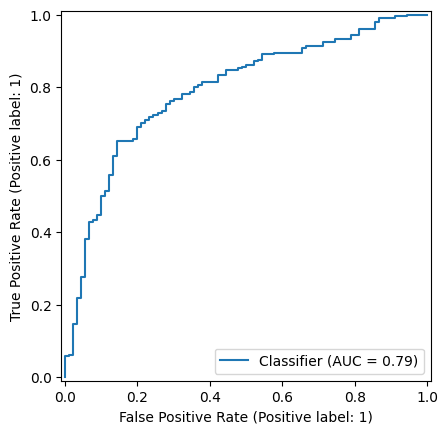

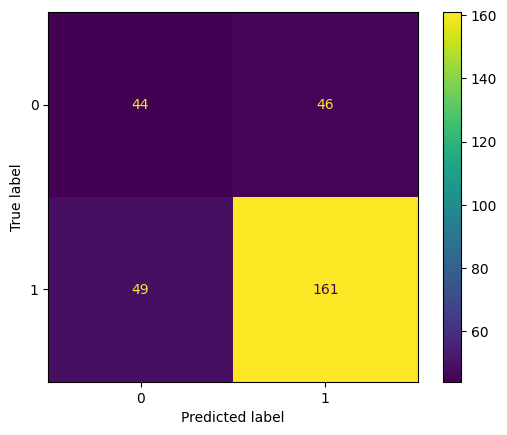

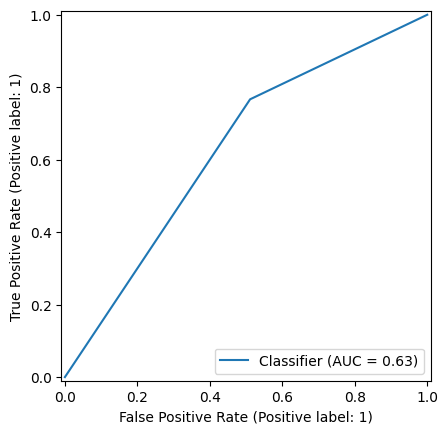

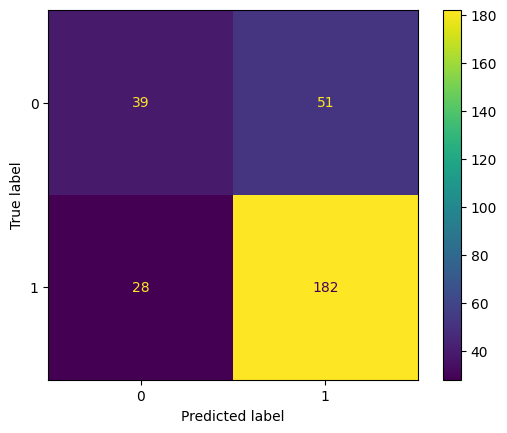

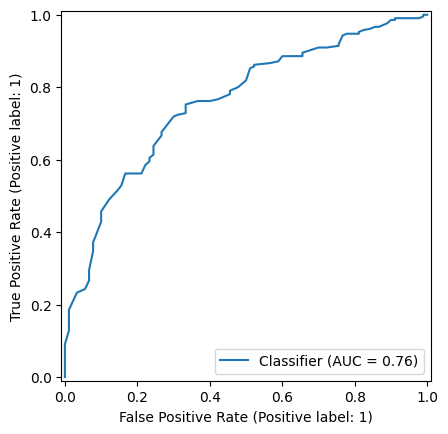

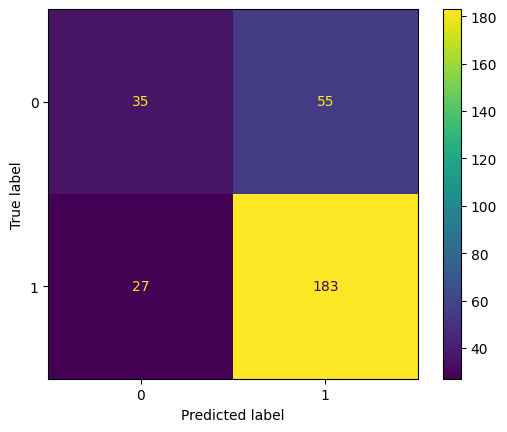

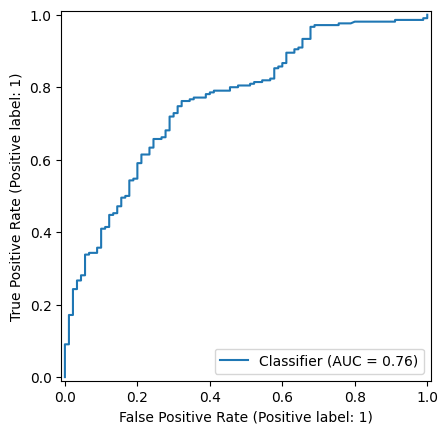

In [ ]:
for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    # Predykcja klas i prawdopodobieństw
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    # ROC AUC
    score = roc_auc_score(y_test, y_prob)
    print(f"{name} ROC AUC: {score:.3f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"{name} Confusion Matrix:")
    print(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot()
    
    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_prob)